---

# MID-COURSE PROJECT 

---

---

## ASSIGNMENT: MID-COURSE PROJECT

>NEW MESSAGE
>August 23, 2022
>From: Ross Retail (Head of Analytics)
>
>Subject: Maven Acquisition Target Data

Hi there,
This is going to be a deep dive analysis presented to senior management at our company. Maven MegaMart is planning to acquire another retailer to expand our market share. As part of the due diligence process, they've sent us over several tables relating to their customers and sales.

I've taken a quick look, but given your great work so far I want you to lead on this. There are some more detailed questions in the attached notebook.

Thanks!

>`Key Objectives`
>
>- Read in data from multiple csv files
>- Explore the data (millions of rows!)
>- Create new columns to aid in analysis
>- Filter, sort, and aggregate the data to pinpoint and summarize important information
>- Build plots to communicate key insights

---

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

<br><br>

---

## First Dataset: "project_transactions.csv"

In [2]:
transactions = pd.read_csv('Data/project_transactions.csv')

transactions.head()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,1364,26984896261,1,842930,1,2.19,31742,0.00,1,0.0,0.0
1,1364,26984896261,1,897044,1,2.99,31742,-0.40,1,0.0,0.0
2,1364,26984896261,1,920955,1,3.09,31742,0.00,1,0.0,0.0
3,1364,26984896261,1,937406,1,2.50,31742,-0.99,1,0.0,0.0
4,1364,26984896261,1,981760,1,0.60,31742,-0.79,1,0.0,0.0


In [3]:
transactions.info(memory_usage='deep', show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2146311 entries, 0 to 2146310
Data columns (total 11 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   household_key      2146311 non-null  int64  
 1   BASKET_ID          2146311 non-null  int64  
 2   DAY                2146311 non-null  int64  
 3   PRODUCT_ID         2146311 non-null  int64  
 4   QUANTITY           2146311 non-null  int64  
 5   SALES_VALUE        2146311 non-null  float64
 6   STORE_ID           2146311 non-null  int64  
 7   RETAIL_DISC        2146311 non-null  float64
 8   WEEK_NO            2146311 non-null  int64  
 9   COUPON_DISC        2146311 non-null  float64
 10  COUPON_MATCH_DISC  2146311 non-null  float64
dtypes: float64(4), int64(7)
memory usage: 180.1 MB


In [4]:
cols = ['QUANTITY','SALES_VALUE', 'RETAIL_DISC', 'COUPON_DISC','COUPON_MATCH_DISC']

transactions[cols].describe().round()

,QUANTITY,SALES_VALUE,RETAIL_DISC,COUPON_DISC,COUPON_MATCH_DISC
count,2146311.0,2146311.0,2146311.0,2146311.0,2146311.0
mean,101.0,3.0,-1.0,-0.0,-0.0
std,1152.0,4.0,1.0,0.0,0.0
min,0.0,0.0,-130.0,-56.0,-8.0
25%,1.0,1.0,-1.0,0.0,0.0
50%,1.0,2.0,0.0,0.0,0.0
75%,1.0,3.0,0.0,0.0,0.0
max,89638.0,840.0,4.0,0.0,0.0


<br><br>

---

## Second Dataset: "products.csv" 

In [5]:
product = pd.read_csv("Data/product.csv")

product.head()

,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
0,25671,2,GROCERY,National,FRZN ICE,ICE - CRUSHED/CUBED,22 LB
1,26081,2,MISC. TRANS.,National,NO COMMODITY DESCRIPTION,NO SUBCOMMODITY DESCRIPTION,
2,26093,69,PASTRY,Private,BREAD,BREAD:ITALIAN/FRENCH,
3,26190,69,GROCERY,Private,FRUIT - SHELF STABLE,APPLE SAUCE,50 OZ
4,26355,69,GROCERY,Private,COOKIES/CONES,SPECIALTY COOKIES,14 OZ


In [6]:
product.info(memory_usage='deep', show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92353 entries, 0 to 92352
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   PRODUCT_ID            92353 non-null  int64 
 1   MANUFACTURER          92353 non-null  int64 
 2   DEPARTMENT            92353 non-null  object
 3   BRAND                 92353 non-null  object
 4   COMMODITY_DESC        92353 non-null  object
 5   SUB_COMMODITY_DESC    92353 non-null  object
 6   CURR_SIZE_OF_PRODUCT  92353 non-null  object
dtypes: int64(2), object(5)
memory usage: 27.6 MB


<br><br>

---

# 1.Introductory Work - Inspection


<span style='color:cyan'>
    
Hi There, and thanks for your help. If you're reading this you've been selected to help on a secret initiative.

You will be helping us analyze a portion of data from a company we want to acquire, which could greatly improve the fortunes of Maven Mega Mart.

We'll be working with `project_transactions.csv` and briefly take a look at `product.csv`.

First, read in the transactions data and explore it.

* Take a look at the raw data, the datatypes, and cast `DAY`, `QUANTITY`, `STORE_ID`, and `WEEK_NO` columns to the smallest appropriate datatype. Check the memory reduction by doing so.
* Is there any missing data?
* How many unique households and products are there in the data? The fields household_key and Product_ID will help here.

<br><br>

---

## 1.1. Memory Reduction

In [7]:
transactions

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,1364,26984896261,1,842930,1,2.19,31742,0.00,1,0.0,0.0
1,1364,26984896261,1,897044,1,2.99,31742,-0.40,1,0.0,0.0
2,1364,26984896261,1,920955,1,3.09,31742,0.00,1,0.0,0.0
3,1364,26984896261,1,937406,1,2.50,31742,-0.99,1,0.0,0.0
4,1364,26984896261,1,981760,1,0.60,31742,-0.79,1,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2146306,1598,42305362535,711,92130,1,0.99,3228,0.00,102,0.0,0.0
2146307,1598,42305362535,711,114102,1,8.89,3228,0.00,102,0.0,0.0
2146308,1598,42305362535,711,133449,1,6.99,3228,0.00,102,0.0,0.0
2146309,1598,42305362535,711,6923644,1,4.50,3228,-0.49,102,0.0,0.0


In [8]:
transactions.dtypes

household_key          int64
BASKET_ID              int64
DAY                    int64
PRODUCT_ID             int64
QUANTITY               int64
SALES_VALUE          float64
STORE_ID               int64
RETAIL_DISC          float64
WEEK_NO                int64
COUPON_DISC          float64
COUPON_MATCH_DISC    float64
dtype: object

In [9]:
transactions = transactions.astype({'household_key':'int16',
                     'DAY':'int16',
                     'PRODUCT_ID':'int32',
                     'QUANTITY':'int16',
                     'SALES_VALUE':'float32',
                     'STORE_ID':'int32',
                     'RETAIL_DISC':'float32',
                     'WEEK_NO':'int8',
                     'COUPON_DISC':'float32',
                     'COUPON_MATCH_DISC':'float32',
                    })

transactions.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2146311 entries, 0 to 2146310
Data columns (total 11 columns):
 #   Column             Dtype  
---  ------             -----  
 0   household_key      int16  
 1   BASKET_ID          int64  
 2   DAY                int16  
 3   PRODUCT_ID         int32  
 4   QUANTITY           int16  
 5   SALES_VALUE        float32
 6   STORE_ID           int32  
 7   RETAIL_DISC        float32
 8   WEEK_NO            int8   
 9   COUPON_DISC        float32
 10  COUPON_MATCH_DISC  float32
dtypes: float32(4), int16(3), int32(2), int64(1), int8(1)
memory usage: 79.8 MB


<br><br>

---

## 1.2. Is there missing data?

In [10]:
# is there any missing data?
transactions.isna().sum()

household_key        0
BASKET_ID            0
DAY                  0
PRODUCT_ID           0
QUANTITY             0
SALES_VALUE          0
STORE_ID             0
RETAIL_DISC          0
WEEK_NO              0
COUPON_DISC          0
COUPON_MATCH_DISC    0
dtype: int64

<br><br>

---

## 1.3. Unique values on `household_key` and `PRODUCT_ID` columns

In [11]:
# How many unique households and products are there in the data? The fields household_key and Product_ID will help here.
transactions.household_key.unique()

array([1364, 1130, 1173, ..., 1077, 1581, 1984],
      shape=(2099,), dtype=int16)

In [12]:
transactions.PRODUCT_ID.unique()

array([  842930,   897044,   920955, ...,   133449,  6923644, 14055192],
      shape=(84138,), dtype=int32)

In [13]:
print('- The column "household_key" has a total of 2099 unique values.\n- The columns "PRODUCT_ID" has a total of 84138 unique values')

- The column "household_key" has a total of 2099 unique values.
- The columns "PRODUCT_ID" has a total of 84138 unique values


<br><br>

---

# 2. Column Creation

Create two columns:

* A column that captures the `total_discount` by row (sum of `RETAIL_DISC`, `COUPON_DISC`)
* The percentage discount (`total_discount` / `SALES_VALUE`). Make sure this is positive (try `.abs()`).
* If the percentage discount is greater than 1, set it equal to 1. If it is less than one, set it to 0. 
* Drop the individual discount columns (`RETAIL_DISC`, `COUPON_DISC`, `COUPON_MATCH_DISC`).

Feel free to overwrite the existing transaction DataFrame after making the modifications above.

In [14]:
transactions.head()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,1364,26984896261,1,842930,1,2.19,31742,0.00,1,0.0,0.0
1,1364,26984896261,1,897044,1,2.99,31742,-0.40,1,0.0,0.0
2,1364,26984896261,1,920955,1,3.09,31742,0.00,1,0.0,0.0
3,1364,26984896261,1,937406,1,2.50,31742,-0.99,1,0.0,0.0
4,1364,26984896261,1,981760,1,0.60,31742,-0.79,1,0.0,0.0


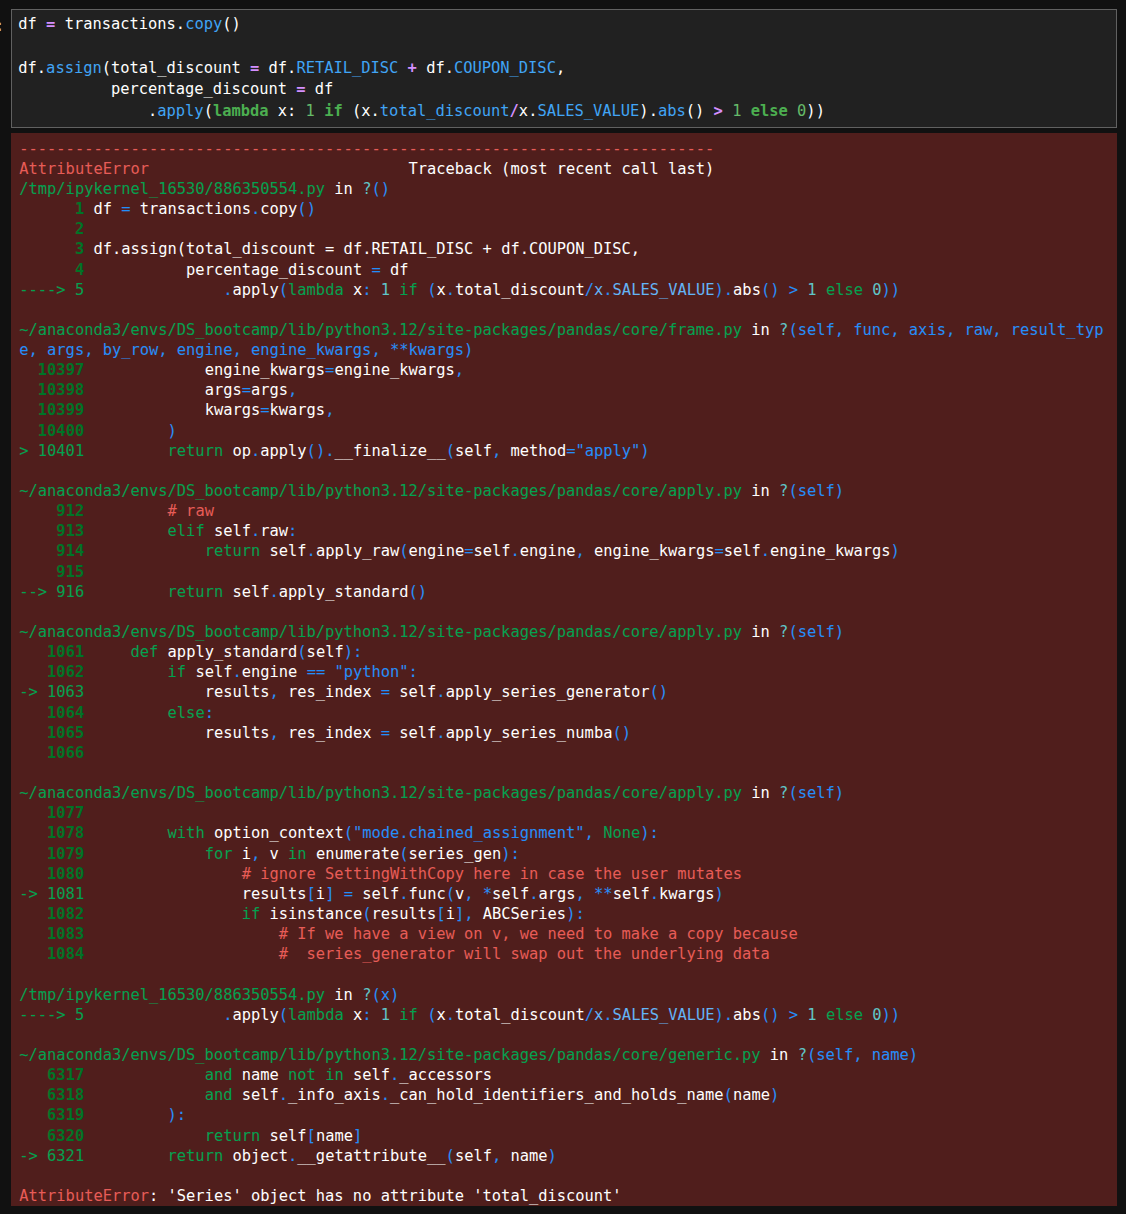

>---
>
>`PREGUNTA: ¿lambda x: vs df.columna directamente?`
>
>La diferencia es sobre cuándo se evalúa la expresión.

```python
# Estilo directo
df = df.assign(total_discount=df.RETAIL_DISC + df.COUPON_DISC)

```

>`df.RETAIL_DISC` se evalúa en el momento en que Python lee esa línea, usando el df que existe en ese instante.

<br>

```python
# Estilo lambda
df = df.assign(total_discount=lambda x: x.RETAIL_DISC + x.COUPON_DISC)
```

>Lambda se evalúa más tarde, cuando `assign()` la invoca internamente, pasándole el DataFrame actual como x.
>
>**¿Cuándo importa esto?**
>
>Importa cuando una columna depende de otra que estás creando en el mismo `assign()`:


```python
df = df.assign(
    total_discount=df.RETAIL_DISC + df.COUPON_DISC,          # df aún no tiene total_discount
    percentage_discount=lambda x: x.total_discount / x.SALES_VALUE  # ✅ x ya la tiene
)
```

<br>

>Si escribieras la segunda línea como `df.total_discount / df.SALES_VALUE`, fallaría porque `df.total_discount` todavía no existe cuando Python lee esa línea.
>
>**Regla práctica:**
>
>- Primera columna en un `assign()` → puedes usar `df.columna` directamente, ambos estilos funcionan igual.
>
>- <span style='color:orange'>Columna que depende de otra creada en el mismo `assign()` → obligatoriamente `lambda`.
>
>- Para consistencia dentro del mismo bloque `assign()` → usa `lambda` en todas, como hice en el ejemplo.
>
>---

In [15]:
df = transactions.copy()
df = (df
    .assign(total_discount = lambda x: x.RETAIL_DISC + x.COUPON_DISC,
            percentage_discount = lambda x: (x.total_discount/x.SALES_VALUE).abs())
)

df.percentage_discount = (np
    .where(df.percentage_discount > 1, 1, 
           np.where(df.percentage_discount < 0, 0, 
                    df.percentage_discount)).round(4)
)

df

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC,total_discount,percentage_discount
0,1364,26984896261,1,842930,1,2.19,31742,0.00,1,0.0,0.0,0.00,0.0000
1,1364,26984896261,1,897044,1,2.99,31742,-0.40,1,0.0,0.0,-0.40,0.1338
2,1364,26984896261,1,920955,1,3.09,31742,0.00,1,0.0,0.0,0.00,0.0000
3,1364,26984896261,1,937406,1,2.50,31742,-0.99,1,0.0,0.0,-0.99,0.3960
4,1364,26984896261,1,981760,1,0.60,31742,-0.79,1,0.0,0.0,-0.79,1.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2146306,1598,42305362535,711,92130,1,0.99,3228,0.00,102,0.0,0.0,0.00,0.0000
2146307,1598,42305362535,711,114102,1,8.89,3228,0.00,102,0.0,0.0,0.00,0.0000
2146308,1598,42305362535,711,133449,1,6.99,3228,0.00,102,0.0,0.0,0.00,0.0000
2146309,1598,42305362535,711,6923644,1,4.50,3228,-0.49,102,0.0,0.0,-0.49,0.1089


In [16]:
df_filt = df[['household_key', 'BASKET_ID', 'DAY', 'PRODUCT_ID', 'QUANTITY',
       'SALES_VALUE', 'STORE_ID', 'WEEK_NO', 'total_discount', 'percentage_discount']]
df_filt

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,WEEK_NO,total_discount,percentage_discount
0,1364,26984896261,1,842930,1,2.19,31742,1,0.00,0.0000
1,1364,26984896261,1,897044,1,2.99,31742,1,-0.40,0.1338
2,1364,26984896261,1,920955,1,3.09,31742,1,0.00,0.0000
3,1364,26984896261,1,937406,1,2.50,31742,1,-0.99,0.3960
4,1364,26984896261,1,981760,1,0.60,31742,1,-0.79,1.0000
...,...,...,...,...,...,...,...,...,...,...
2146306,1598,42305362535,711,92130,1,0.99,3228,102,0.00,0.0000
2146307,1598,42305362535,711,114102,1,8.89,3228,102,0.00,0.0000
2146308,1598,42305362535,711,133449,1,6.99,3228,102,0.00,0.0000
2146309,1598,42305362535,711,6923644,1,4.50,3228,102,-0.49,0.1089


<br><br>

---

# 3. Overall Statistics

Calculate:

* The total sales (sum of `SALES_VALUE`), 
* Total discount (sum of `total_discount`)
* Overall percentage discount (sum of total_discount / sum of sales value)
* Total quantity sold (sum of `QUANTITY`).
* Max quantity sold in a single row. Inspect the row as well. Does this have a high discount percentage?
* Total sales value per basket (sum of sales value / nunique basket_id).
* Total sales value per household (sum of sales value / nunique household_key). 
* What was the highest quantiy sold for a single item in a single row?

In [17]:
# The total sales (sum of SALES_VALUE),
total_sales = df_filt.SALES_VALUE.sum().round()
print(f"{total_sales:,.2f}")

6,666,244.00


In [18]:
# Total discount (sum of total_discount)
total_discount = df_filt.total_discount.sum()
print(f"{total_discount:,.2f}")

-1,178,658.12


In [19]:
#Overall percentage discount (sum of total_discount / sum of sales value)
percentage_discount = total_discount/total_sales
print(f"{percentage_discount:,.4f}")

-0.1768


In [20]:
#Total quantity sold (sum of QUANTITY).
total_quantity = df_filt.QUANTITY.sum().round()
print(f"{total_quantity:,.2f}")

215,271,819.00


In [21]:
# Max quantity sold in a single row. Inspect the row as well. Does this have a high discount percentage?
df[df.QUANTITY == df.QUANTITY.max()]

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC,total_discount,percentage_discount
153840,630,28270956876,107,6534178,32740,72.0,384,-3.27,16,0.0,0.0,-3.27,0.0454


In [22]:
# Total sales value per basket (sum of sales value / nunique basket_id).
total_sales_basket = total_sales / df_filt.BASKET_ID.nunique()
print(f"{total_sales_basket:,.2f}")

28.62


In [23]:
#Total sales value per household (sum of sales value / nunique household_key).
total_sales_household = total_sales / df_filt.household_key.nunique()
print(f"{total_sales_household:,.2f}")

3,175.91


<br><br>

---

# 4. Household Analysis

* Plot the distribution of total sales value purchased at the household level. 
* What were the top 10 households by quantity purchased?
* What were the top 10 households by sales value?
* Plot the total sales value for our top 10 households by value, ordered from highest to lowest.


In [24]:
# Plot the distribution of total sales value purchased at the household level.
df_plot1 = df_filt.groupby('household_key').agg({'SALES_VALUE':'sum'})

df_plot1

,SALES_VALUE
household_key,
1,4330.160156
2,1954.339966
3,2653.209961
4,1200.109985
5,779.059998
...,...
2095,3790.489990
2096,1301.650024
2097,8823.830078


<Axes: ylabel='Frequency'>

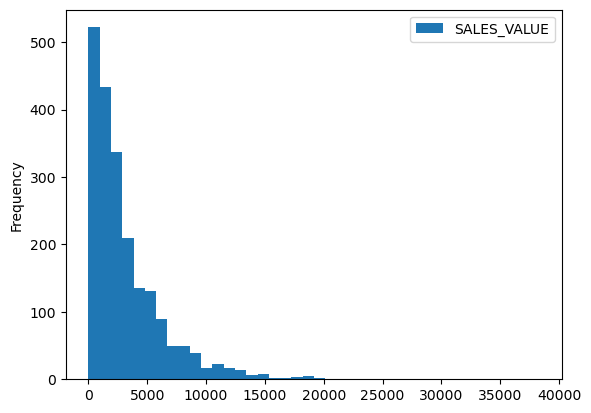

In [25]:
df_plot1.plot.hist(bins=40)

In [26]:
# What were the top 10 households by quantity purchased?
(df_filt
    .groupby('household_key')
    .agg({'QUANTITY': 'sum'})
    .sort_values('QUANTITY', ascending=False)
    .head(10)
)

,QUANTITY
household_key,
1023,4479917
755,3141769
1609,2146715
13,1863829
1430,1741892
1527,1734632
1762,1669880
707,1640193
1029,1496204


In [27]:
# What were the top 10 households by sales value?
top_house_sales = (df_filt
    .groupby('household_key')
    .agg({'SALES_VALUE':'sum'})
    .sort_values('SALES_VALUE', ascending=False)
    .head(10)
)

top_house_sales

,SALES_VALUE
household_key,
1023,38319.789062
1609,27859.679688
1453,21661.289062
1430,20352.990234
718,19299.859375
707,19194.419922
1653,19153.750000
1111,18894.720703
982,18790.339844


<Axes: xlabel='household_key'>

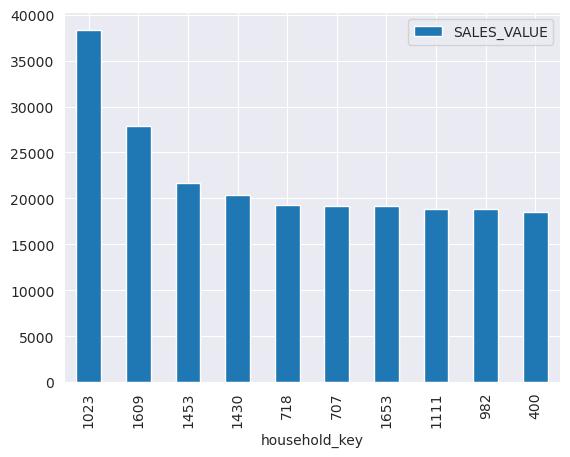

In [28]:
# Plot the total sales value for our top 10 households by value, ordered from highest to lowest.
sns.set_style('darkgrid')

top_house_sales.plot.bar()

<br><br>

---

# 5. Product Analysis

* Which products had the most sales by sales_value? Plot  a horizontal bar chart.
* Did the top selling items have a higher than average discount rate?
* Look up the names of the  top 10 products by sales in the `products.csv` dataset.
* What was the name most common `PRODUCT_ID` among rows with the households in our top 10 households by sales value?
* Look up the product name of the item that had the highest quantity sold in a single row.

In [29]:
# Which products had the most sales by sales_value? Plot a horizontal bar chart.
max_sale_product = (df_filt
    .groupby('PRODUCT_ID')
    .agg({'SALES_VALUE':'sum'})
    .sort_values('SALES_VALUE', ascending=False)
    .head(10)
)
max_sale_product

,SALES_VALUE
PRODUCT_ID,
6534178,420154.125000
6533889,42339.308594
1029743,33894.750000
1082185,24149.789062
6533765,23831.140625
6534166,23755.699219
1106523,22931.009766
916122,22749.019531
995242,21229.720703


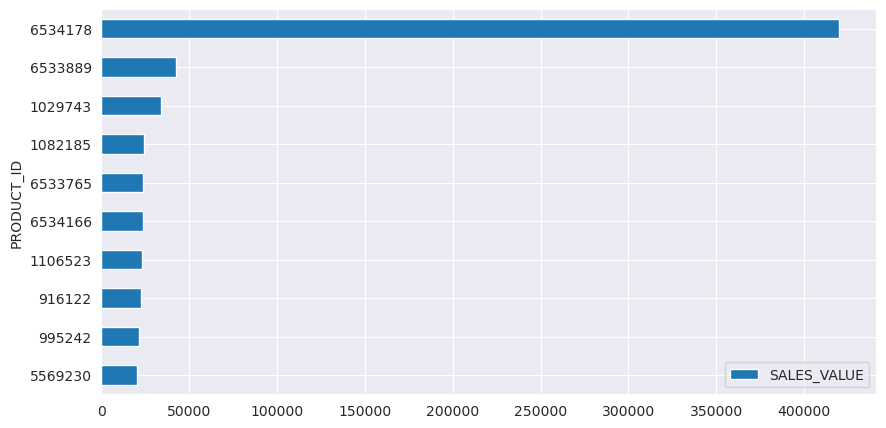

In [30]:
sns.set_style('darkgrid')

max_sale_product[::-1].plot.barh(figsize=(10, 5));

In [31]:
# Did the top selling items have a higher than average discount rate?
(df_filt
    .query("PRODUCT_ID in @max_sale_product.index")
    .loc[:, 'total_discount']
    .sum())/(df_filt
    .query("PRODUCT_ID in @max_sale_product.index")
    .loc[:, 'SALES_VALUE']
    .sum()
)


np.float32(-0.10331267)

In [32]:
# Look up the names of the top 10 products by sales in the products.csv dataset.
top_products = (df_filt
    .query("household_key in @top_house_sales.index")
    .loc[:,'PRODUCT_ID']
    .value_counts('PRODUCT_ID', ascending=False)
    .head(10)
    .index
)

top_products

Index([1082185, 1029743, 6534178, 6533889, 1127831,  951590,  860776, 1106523,
        981760, 9677202],
      dtype='int32', name='PRODUCT_ID')

In [33]:
product.query("PRODUCT_ID in @top_products")

,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
10630,860776,2,PRODUCE,National,VEGETABLES - ALL OTHERS,CUCUMBERS,36 CT
20973,951590,910,GROCERY,National,BAKED BREAD/BUNS/ROLLS,MAINSTREAM WHITE BREAD,20 OZ
24250,981760,69,GROCERY,Private,EGGS,EGGS - X-LARGE,1 DZ
29657,1029743,69,GROCERY,Private,FLUID MILK PRODUCTS,FLUID MILK WHITE ONLY,1 GA
35576,1082185,2,PRODUCE,National,TROPICAL FRUIT,BANANAS,40 LB
38262,1106523,69,GROCERY,Private,FLUID MILK PRODUCTS,FLUID MILK WHITE ONLY,1 GA
40600,1127831,5937,PRODUCE,National,BERRIES,STRAWBERRIES,16 OZ
57181,6533889,69,MISC SALES TRAN,Private,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,
57221,6534178,69,KIOSK-GAS,Private,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,
68952,9677202,69,GROCERY,Private,PAPER TOWELS,PAPER TOWELS & HOLDERS,


In [34]:
# Product with highest quantity in a single row

product.query("PRODUCT_ID == 6534178")

,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
57221,6534178,69,KIOSK-GAS,Private,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,


In [35]:
# Look up 10 product names for all customers (from first cell)

product.query("PRODUCT_ID in @max_sale_product.index")

,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
16863,916122,4314,MEAT,National,CHICKEN,CHICKEN BREAST BONELESS,
25754,995242,69,GROCERY,Private,FLUID MILK PRODUCTS,FLUID MILK WHITE ONLY,
29657,1029743,69,GROCERY,Private,FLUID MILK PRODUCTS,FLUID MILK WHITE ONLY,1 GA
35576,1082185,2,PRODUCE,National,TROPICAL FRUIT,BANANAS,40 LB
38262,1106523,69,GROCERY,Private,FLUID MILK PRODUCTS,FLUID MILK WHITE ONLY,1 GA
53097,5569230,1208,GROCERY,National,SOFT DRINKS,SOFT DRINKS 12/18&15PK CAN CAR,12 OZ
57171,6533765,69,KIOSK-GAS,Private,FUEL,GASOLINE-REG UNLEADED,
57181,6533889,69,MISC SALES TRAN,Private,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,
57216,6534166,69,MISC SALES TRAN,Private,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,
57221,6534178,69,KIOSK-GAS,Private,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,
